In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score,confusion_matrix, roc_curve, roc_auc_score, auc)

In [ ]:
data = pd.read_csv("samples_cancer.csv")
data.head()

,ID,Clump,UnifSize,UnifShape,MargAdh,SingEpiSize,BareNuc,BlandChrom,NormNucl,Mit,Class
0,1000025,5,1,1,1,2,1,3,1,1,2
1,1002945,5,4,4,5,7,10,3,2,1,2
2,1015425,3,1,1,1,2,2,3,1,1,2
3,1016277,6,8,8,1,3,4,3,7,1,2
4,1017023,4,1,1,3,2,1,3,1,1,2


In [ ]:
rows_to_drop = data[data["BareNuc"] == "?"].index
data.drop(rows_to_drop, inplace=True)
data["BareNuc"] = data["BareNuc"].astype(int)

In [ ]:
data["Class"] = data["Class"].map({2: 0, 4: 1})

In [ ]:
numerical_columns = ["Clump", "UnifSize", "UnifShape", "MargAdh","SingEpiSize",
                     "BareNuc", "BlandChrom", "NormNucl", "Mit"]

X = data[numerical_columns]
y = data["Class"]

In [ ]:
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [ ]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

In [ ]:
acc = accuracy_score(y_test, y_pred)
p = precision_score(y_test, y_pred)
r = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc_val = roc_auc_score(y_test, y_proba)

print("📊 MODEL PERFORMANCE")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {p:.4f}")
print(f"Recall   : {r:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"AUC      : {auc_val:.4f}")

📊 MODEL PERFORMANCE
Accuracy : 0.9489
Precision: 0.9811
Recall   : 0.8966
F1 Score : 0.9369
AUC      : 0.9978


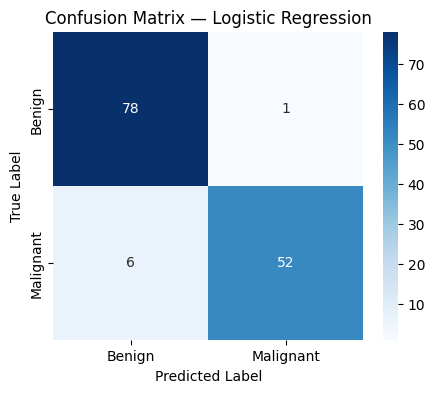

In [ ]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Benign','Malignant'], yticklabels=['Benign','Malignant'])
plt.title("Confusion Matrix — Logistic Regression")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

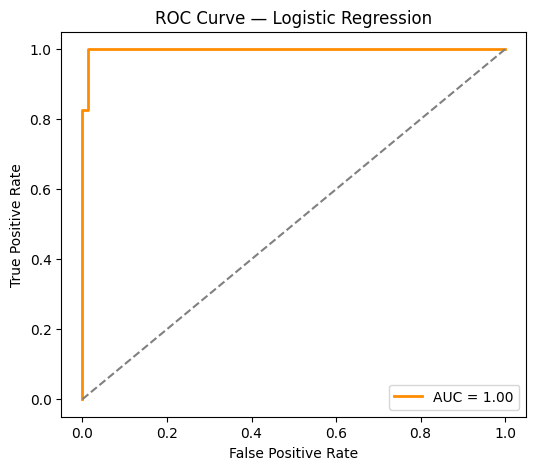

In [ ]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Logistic Regression")
plt.legend(loc="lower right")
plt.show()